# **DESAFIO ALURA TELECOM**

##**Preparación del ambiente**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##**Etapa 1: Ingesta de Datos (Data Ingestion)**

In [2]:
df_telecom = pd.read_json('TelecomX_Data.json')
df_telecom.head(5)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
print(df_telecom.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


##**Etapa 2: Estructuración de Datos**.

In [4]:
# Normalización de la estructura JSON a DataFrame
df_telecom_norm = pd.json_normalize(df_telecom.to_dict('records'), sep='_')

df_telecom_norm.head(5)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
print(df_telecom_norm.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

## Nota técnica E2:
  Tras la ingesta y el aplanamiento de los datos, se identificaron tres puntos críticos en la estructura: la columna account.Charges.Total se cargó como texto (object), debiendo ser float64. Adicionalemente, se observa que la nomenclatura con prefijos preserva la jerarquía original del JSON.
  
  Para abordar los hallazgos anteriores, el siguiente bloque de código ejecuta una normalización integral de tipos, para garantizar la integridad técnica para las etapas de análisis exploratorio desde esta perspectiva.

##**Etapa 3: Normalización de Tipos Primarios.**

In [7]:
# 5.1. Tratamiento de valores nulos y tipos de datos
# Estandarización de tipos antes de la limpieza profunda.
df_telecom_norm['account_Charges_Total'] = pd.to_numeric(df_telecom_norm['account_Charges_Total'], errors='coerce')

cols_cualitativas = [
    'customer_gender', 'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
    'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection',
    'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'Churn'
]

for col in cols_cualitativas:
    df_telecom_norm[col] = df_telecom_norm[col].astype(str)

df_telecom_norm['customer_SeniorCitizen'] = df_telecom_norm['customer_SeniorCitizen'].astype(int)

# Imputación por lógica de negocio (tenure 0 -> total charges 0).
df_telecom_norm['account_Charges_Total'] = df_telecom_norm['account_Charges_Total'].fillna(0.0)

# Verificación de integridad financiera
print(f'Nulos remanentes en charges.total: {df_telecom_norm["account_Charges_Total"].isna().sum()}')

df_telecom_norm.info()

Nulos remanentes en charges.total: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_Te

##Nota técnica E3.
 Se ejecutó la normalización de tipos primarios, forzando la conversión de la facturación acumulada (Charges.Total) a formato numérico. Este proceso expuso inmediatamente 11 registros con latencia financiera (NaN) que estaban ocultos como texto. Estos casos quedan identificados para una revisión de origen en la siguiente etapa. El resto del dataset queda estandarizado.

##**Etapa 4: Revisión de Calidad y Limpieza de Datos**.

### 4.1 Limpieza de Integridad.

In [9]:
# Identificación de registros con latencia financiera (NaN).
nulos_financieros = df_telecom_norm['account_Charges_Total'].isna().sum()

# Validación de origen.
perfil_nulos = df_telecom_norm[df_telecom_norm['account_Charges_Total'].isna()]['customer_tenure'].unique()

print(f'Hallazgo: {nulos_financieros} registros con latencia en cargos totales (NaN).')
print(f'Antigüedad de los registros afectados (tenure): {perfil_nulos}')

Hallazgo: 0 registros con latencia en cargos totales (NaN).
Antigüedad de los registros afectados (tenure): []


###Nota técnica 4.1:
  Los 11 valores nulos detectados en la facturación acumulada son consistentes con la lógica de negocio de altas nuevas (tenure = 0). No representan una pérdida de integridad, sino una latencia contable. Se resolverá su imputación a cero en la fase de saneamiento.

###4.2. Revisión de Duplicados e Identidad.

In [10]:
# 4.2. Verificación de posibles anomalías estructurales en customerID.
reporte_id = {
    'Nulos (nan/none)': df_telecom_norm['customerID'].isna().sum(),
    "Cadenas vacías ('')": (df_telecom_norm['customerID'] == '').sum(),
    "Espacios (' ')": (df_telecom_norm['customerID'] == ' ').sum(),
    'valores cero (0)': df_telecom_norm['customerID'].isin([0, '0']).sum()
}

print('Resultados de Identidad:')
for hallazgo, cantidad in reporte_id.items():
    print(f'{hallazgo}: {cantidad}')

print(f"\nEstado: {'identidad validada' if df_telecom_norm['customerID'].nunique() == len(df_telecom_norm) else 'alerta de duplicidad'}")

Resultados de Identidad:
Nulos (nan/none): 0
Cadenas vacías (''): 0
Espacios (' '): 0
valores cero (0): 0

Estado: identidad validada


###Nota técnica 4.2:
La validación del customerID confirma la ausencia de anomalías estructurales como registros huérfanos, cadenas vacías o duplicidad de identidad. Con un universo de 7,267 registros únicos y una integridad del 100%, el dataset garantiza la trazabilidad individual de cada cliente, condición necesaria para asegurar que el cálculo de ROAS y LTV no presente sesgos por fragmentación de datos.

### 4.3 Diagnóstico General de Etiquetas y Niveles.

In [11]:
# Inspección de etiquetas y simetría.
threshold = 10
inspeccion_data = []
columnas_inspeccion = [col for col in df_telecom_norm.columns if df_telecom_norm[col].nunique() < threshold]

for col in columnas_inspeccion:
    valores = df_telecom_norm[col].unique().tolist()
    inspeccion_data.append({
        'Atributo': col,
        'Niveles': len(valores),
        'Etiquetas Detectadas': valores
    })

df_Limpieza = pd.DataFrame(inspeccion_data).sort_values(by='Niveles', ascending=False)
display(df_Limpieza.style.hide(axis='index'))

Atributo,Niveles,Etiquetas Detectadas
account_PaymentMethod,4,"['Mailed check', 'Electronic check', 'Credit card (automatic)', 'Bank transfer (automatic)']"
Churn,3,"['No', 'Yes', '']"
internet_InternetService,3,"['DSL', 'Fiber optic', 'No']"
phone_MultipleLines,3,"['No', 'Yes', 'No phone service']"
internet_OnlineSecurity,3,"['No', 'Yes', 'No internet service']"
internet_DeviceProtection,3,"['No', 'Yes', 'No internet service']"
internet_TechSupport,3,"['Yes', 'No', 'No internet service']"
internet_OnlineBackup,3,"['Yes', 'No', 'No internet service']"
internet_StreamingTV,3,"['Yes', 'No', 'No internet service']"
account_Contract,3,"['One year', 'Month-to-month', 'Two year']"


###Nota técnica 4.3:
 El diagnóstico detecta una ruptura de integridad por la presencia de cadenas vacías ('') en Churn y fragmentación de estados en los servicios bajo la etiqueta "No internet service". La tabla muestra niveles de información sucios que afectan la simetría del dataset. Se debe efectuar una normalización coercitiva.

###4.4 Validación de Consistencia Estructural.

In [12]:
# Reporte final para cierre de etapa.
n_registros = len(df_telecom_norm)
certificacion = pd.DataFrame({
    'atributo': df_telecom_norm.columns,
    'es_pk': df_telecom_norm.nunique().values == n_registros,
    '%_unicidad': (df_telecom_norm.nunique().values / n_registros) * 100
}).sort_values(by='%_unicidad', ascending=False)

print(f'Resumen de levantamiento (n = {n_registros})')
display(certificacion.style.format({'%_unicidad': '{:.2f}%'}).hide(axis='index'))

Resumen de levantamiento (n = 7267)


atributo,es_pk,%_unicidad
customerID,True,100.00%
account_Charges_Total,False,89.87%
account_Charges_Monthly,False,21.81%
customer_tenure,False,1.00%
account_PaymentMethod,False,0.06%
account_Contract,False,0.04%
internet_StreamingMovies,False,0.04%
internet_DeviceProtection,False,0.04%
Churn,False,0.04%
internet_OnlineBackup,False,0.04%


### Nota técnica 4.4:
El diagnóstico confirma que el customerID opera como una llave primaria íntegra, con un 100% de unicidad. La distribución de densidad por atributo permite identificar variables de alta resolución  y variables segmentables. Esta validación cierra la fase de levantamiento, garantizando que no existen duplicidades que generen sesgos.

##**Etapa 5: Limpieza para la Estabilización Estructural del Dataset.**

Concluido el Limpieza de integridad, se inicia la fase de Limpieza sobre el dataset.
Esta etapa tiene como objetivo neutralizar las anomalías detectadas en la fase previa, buscando que cada registro aporte una señal limpia al análisis de negocio.

###5.1. Imputación técnica de vacíos en facturación.

In [13]:
# Imputación por lógica de negocio (tenure 0 -> total charges 0).
df_telecom_norm['account_Charges_Total'] = df_telecom_norm['account_Charges_Total'].fillna(0.0)

print(f'Nulos remanentes en charges.total: {df_telecom_norm["account_Charges_Total"].isna().sum()}')


Nulos remanentes en charges.total: 0


###Nota técnica 5.1:
 La Limpieza resuelve el hallazgo del punto 4.1 mediante la imputación de valor cero en registros con antigüedad nula. Esta acción garantiza la integridad del vector de facturación sin recurrir a la eliminación de filas, preservando la densidad del dataset para el análisis.

###5.2 Normalización de arquitectura de servicios.


In [14]:
# Reducción de cardinalidad.
columnas_ruido = [
    'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection',
    'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'phone_MultipleLines'
]

for col in columnas_ruido:
    df_telecom_norm[col] = df_telecom_norm[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

reporte_simetria = df_telecom_norm[columnas_ruido].nunique()
print('Verificación de Simetría en Servicios:')
print(reporte_simetria)

Verificación de Simetría en Servicios:
internet_OnlineSecurity      2
internet_OnlineBackup        2
internet_DeviceProtection    2
internet_TechSupport         2
internet_StreamingTV         2
internet_StreamingMovies     2
phone_MultipleLines          2
dtype: int64


### Nota técnica 5.2:
 La normalización elimina la fragmentación artificial de la oferta de servicios. Al colapsar los estados de "No servicio" en un "No" unificado, se incrementa la densidad de información por categoría.

###5.3 Resolución de Ruptura de Integridad y Resultado del Target.

In [15]:
# Acción sobre de registros con indeterminación en Churn.
n_inicial = len(df_telecom_norm)
df_telecom_norm = df_telecom_norm[df_telecom_norm['Churn'] != ''].copy()
n_final = len(df_telecom_norm)

# Validación de pureza del Target.
niveles_target = df_telecom_norm['Churn'].unique()

print(f'Limpieza de registros sin etiqueta de Churn.')
print(f'Registros con Churn vacío removidos: {n_inicial - n_final}')
print(f'Niveles remanentes: {niveles_target}')

if len(niveles_target) == 2:
    print('Estado: Target certificado para modelado predictivo.')
else:
    raise ValueError('¡Error!: El target aún presenta niveles indeterminados.')

print(df_telecom_norm['Churn'].unique())

Limpieza de registros sin etiqueta de Churn.
Registros con Churn vacío removidos: 224
Niveles remanentes: ['No' 'Yes']
Estado: Target certificado para modelado predictivo.
['No' 'Yes']


### Nota 5.3
 Esta intervención resuelve la ruptura de integridad detectada en el Limpieza 4.3, reduciendo el universo a 7,256 registros. Al purgar la indeterminación se eliminan sesgos.

###5.4. Ajustes de tipos y ahorro de memoria.

In [16]:
# Optimización de Tipos de Datos y Memoria.
for col in df_telecom_norm.columns:
    if col == 'customerID':
        continue

    if 'Charges' in col or 'tenure' in col:
        df_telecom_norm[col] = pd.to_numeric(df_telecom_norm[col], errors='coerce')
    else:
        df_telecom_norm[col] = df_telecom_norm[col].astype('category')

print('Resultado de estructura final:')
df_telecom_norm.info()

memoria_mb = df_telecom_norm.memory_usage(deep=True).sum() / 1024**2
print(f'\nHuella de memoria final: {memoria_mb:.2f} MB')

Resultado de estructura final:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   customerID                 7043 non-null   object  
 1   Churn                      7043 non-null   category
 2   customer_gender            7043 non-null   category
 3   customer_SeniorCitizen     7043 non-null   category
 4   customer_Partner           7043 non-null   category
 5   customer_Dependents        7043 non-null   category
 6   customer_tenure            7043 non-null   int64   
 7   phone_PhoneService         7043 non-null   category
 8   phone_MultipleLines        7043 non-null   category
 9   internet_InternetService   7043 non-null   category
 10  internet_OnlineSecurity    7043 non-null   category
 11  internet_OnlineBackup      7043 non-null   category
 12  internet_DeviceProtection  7043 non-null   category
 13  interne

### Nota técnica:
La intervención final ha reestructurado el dataset para garantizar eficiencia computacional y estabilidad en el modelado. Se ha aplicado una segregación lógica de tipos: las métricas financieras y de antigüedad conservan su naturaleza numérica (float64/int64) para permitir cálculos de correlación, mientras que los 17 atributos cualitativos han sido convertidos a category.

Esta optimización reduce la huella de memoria a 0.73 MB y elimina la ambigüedad de los objetos de texto genéricos. El resultado es un activo de datos blindado contra inconsistencias, que facilita el encoding automático y asegura la simetría estructural necesaria para el entrenamiento del modelo de Machine Learning.

##**Etapa 6: Análisis Exploratorio de Datos.**

### 6.1. Métricas de Control.

In [17]:
# Estadísticos Descriptivos de Variables Numéricas.
print('Resumen de Magnitudes (Finanzas y Ciclo de Vida):')
stats_num = df_telecom_norm.describe().T
display(stats_num[['mean', 'std', 'min', '50%', 'max']].round(2))

# Resumen de Atributos Categóricos
print('\nDistribución de Atributos de Servicio y Cuenta:')
stats_cat = df_telecom_norm.describe(include='category').T
display(stats_cat[['count', 'unique', 'top', 'freq']])

Resumen de Magnitudes (Finanzas y Ciclo de Vida):


,mean,std,min,50%,max
customer_tenure,32.37,24.56,0.00,29.00,72.00
account_Charges_Monthly,64.76,30.09,18.25,70.35,118.75
account_Charges_Total,2279.73,2266.79,0.00,1394.55,8684.80



Distribución de Atributos de Servicio y Cuenta:


,count,unique,top,freq
Churn,7043,2,No,5174
customer_gender,7043,2,Male,3555
customer_SeniorCitizen,7043,2,0,5901
customer_Partner,7043,2,No,3641
customer_Dependents,7043,2,No,4933
phone_PhoneService,7043,2,Yes,6361
phone_MultipleLines,7043,2,No,4072
internet_InternetService,7043,3,Fiber optic,3096
internet_OnlineSecurity,7043,2,No,5024
internet_OnlineBackup,7043,2,No,4614


### Diagnóstico:
Volatilidad Financiera: La desviación estándar de Charges.Total es significativamente alta, lo que confirma una base de clientes con ciclos de vida muy dispares. Punto de Equilibrio: El 50% de la cartera tiene menos de 29 meses de antigüedad (tenure). Los esfuerzos deben concentrarse en este segmento joven antes de que alcancen su etapa de madurez o fuga.

###6.2 Magnitud de la Evasión

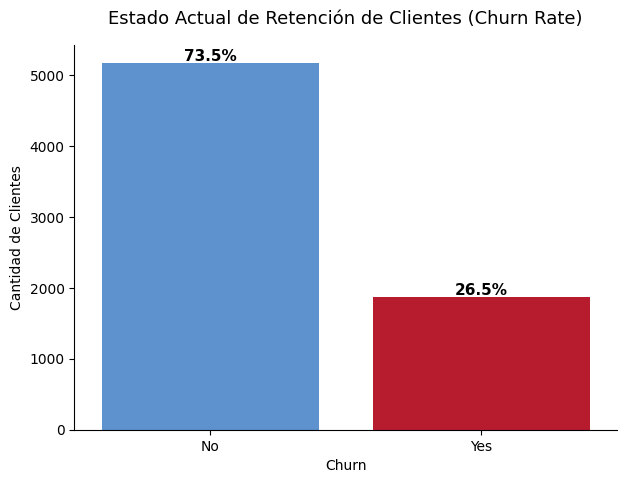

In [18]:
# Análisis de Desequilibrio del Target.
colores_exec = ['#4A90E2', '#D0021B'] # Azul (Lealtad) / Rojo (Fuga)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_telecom_norm, x='Churn', hue='Churn',
                   palette=colores_exec, legend=False)

total_clientes = len(df_telecom_norm)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height()/total_clientes:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width()/2., p.get_height() + 100),
                ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Estado Actual de Retención de Clientes (Churn Rate)', fontsize=13, pad=15)
plt.ylabel('Cantidad de Clientes')
sns.despine()
plt.show()

### Insight de Negocio
 Una tasa de evasión del 26.5% representa un riesgo alto. En el contexto, esto indica que 1 de cada 4 esfuerzos de marketing se pierde por falta de retención.

###6.3. Análisis Bivariado: Segmentación de Riesgo de Servicio.

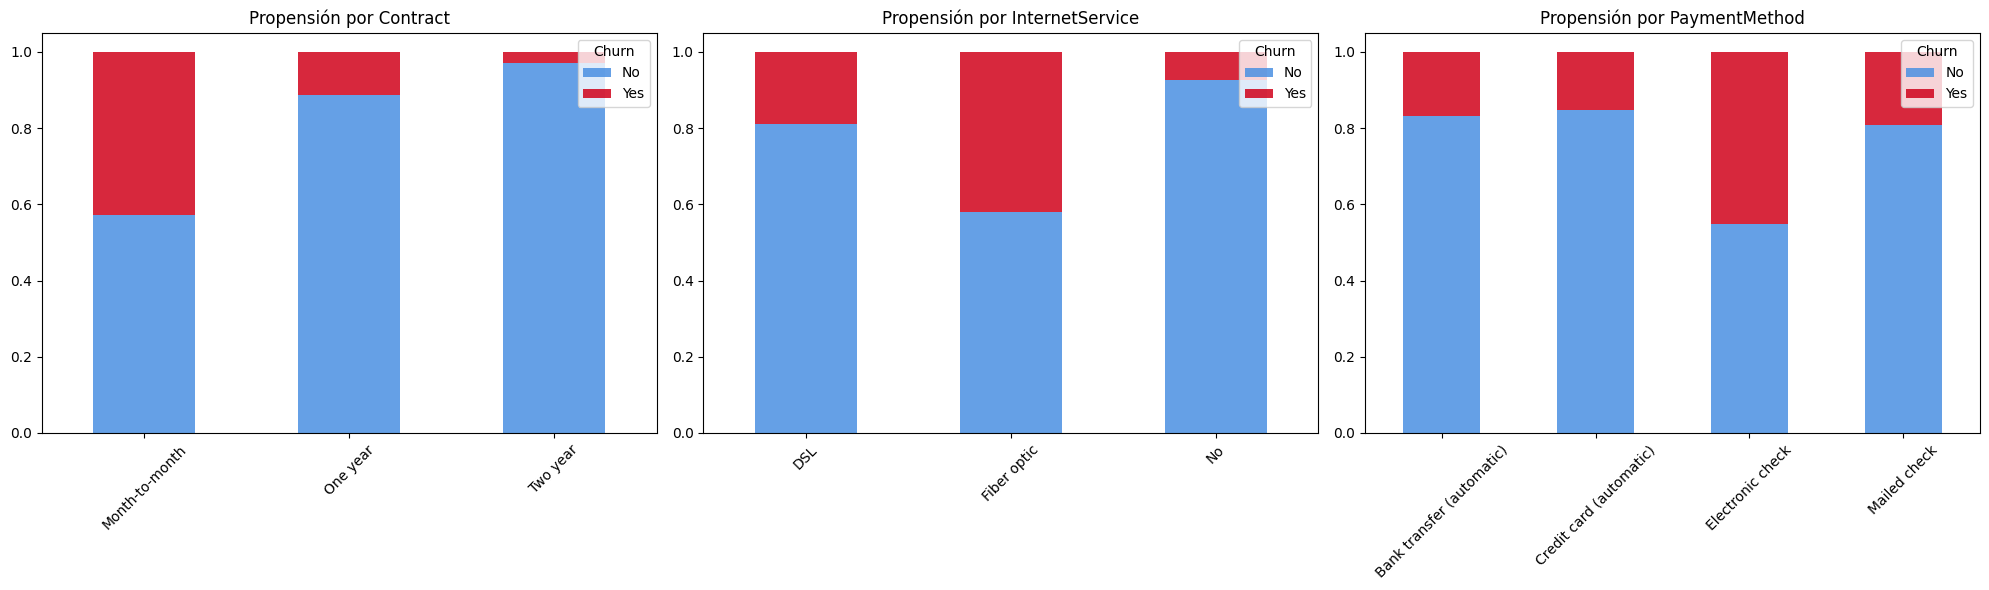

Probabilidad de Evasión por Segmento (%):


Churn,No,Yes
account_Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


Churn,No,Yes
internet_InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


Churn,No,Yes
account_PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [29]:
# Análisis Bivariado de Propensión.
vars_bivariadas = ['account_Contract', 'internet_InternetService', 'account_PaymentMethod']
colores_exec = ['#4A90E2', '#D0021B']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(vars_bivariadas):
      crosstab_norm = pd.crosstab(df_telecom_norm[col], df_telecom_norm['Churn'], normalize='index')
      crosstab_norm.plot(kind='bar', stacked=True, ax=axes[i], color=colores_exec, alpha=0.85)
      axes[i].set_title(f"Propensión por {col.split('_')[-1]}", fontsize=12)
      axes[i].set_xlabel('')
      axes[i].tick_params(axis='x', rotation=45)
      axes[i].legend(title='Churn', loc='upper right')

plt.tight_layout()
plt.show()

# Soporte Tabular (El dato duro para el reporte)
print('Probabilidad de Evasión por Segmento (%):')
for col in vars_bivariadas:
    display((pd.crosstab(df_telecom_norm[col], df_telecom_norm['Churn'], normalize='index') * 100).round(2))

###Hallazgos Clave:

 **Contrato**: El modelo "Month-to-month" es el principal motor de fuga (42.71%).

 **Producto**: La Fibra Óptica, aunque es un servicio premium, tiene una tasa de evasión crítica (41.89%). Esto sugiere una falla en la percepción de valor/precio o problemas técnicos recurrentes.

 **Pago**: El método "Electronic check" duplica la probabilidad de fuga respecto a los métodos automáticos.

###6.4. Análisis Numérico para Umbrales de Abandono.

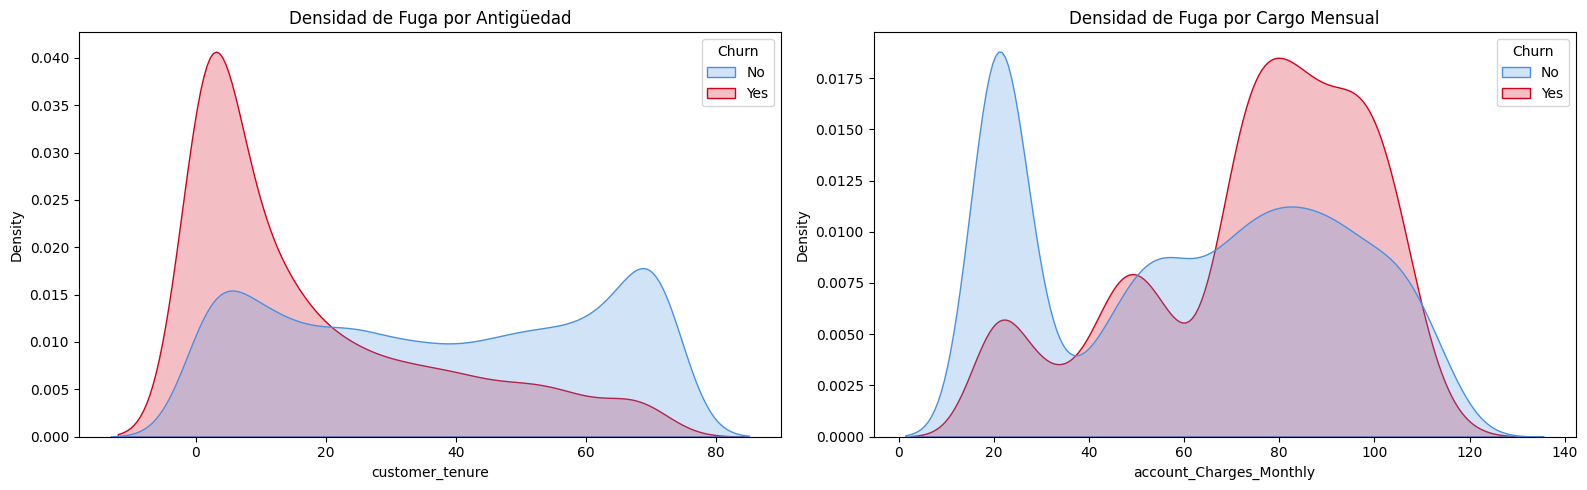

In [30]:
# Análisis de Variables Numéricas para Umbrales de Fuga.
v_tenure = 'customer_tenure'
v_monthly = 'account_Charges_Monthly'
colores_exec = ['#4A90E2', '#D0021B']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de Antigüedad
sns.kdeplot(data=df_telecom_norm, x=v_tenure, hue='Churn', fill=True,
            palette=colores_exec, common_norm=False, ax=axes[0])
axes[0].set_title('Densidad de Fuga por Antigüedad', fontsize=12)

# Distribución de Cargos Mensuales
sns.kdeplot(data=df_telecom_norm, x=v_monthly, hue='Churn', fill=True,
            palette=colores_exec, common_norm=False, ax=axes[1])
axes[1].set_title('Densidad de Fuga por Cargo Mensual', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretación de análisis bivariado.

Análisis de Permanencia: La mayor densidad de fuga ocurre en los primeros 12 meses de relación. Esto sugiere que el proceso de onboarding o las promesas de venta iniciales no están alineadas con la experiencia real del servicio.

Análisis de Facturación: El riesgo de Churn se dispara cuando la factura mensual supera el umbral de los $70. A partir de este punto, el cliente se vuelve altamente sensible al precio, lo que indica que la percepción de valor de los planes premium debe ser reforzada.

### 6.5. Mapa de Correlación Estratégica

In [31]:
# Análisis de Correlación de Pearson para los Drivers de Fuga.
df_num = pd.get_dummies(df_telecom_norm.drop(columns=['customerID']), drop_first=True)

corr_target = df_num.corr()['Churn_Yes'].sort_values(ascending=False).to_frame()
corr_target.columns = ['Fuerza de Correlación']
corr_target.index.name = 'Variable / Driver'

print('Drivers con mayor impacto en la Evasión de Clientes:')
display(corr_target.head(11).round(3))

print('\nDrivers con mayor impacto en la Retención (Correlación Negativa):')
display(corr_target.tail(5).sort_values(by='Fuerza de Correlación').round(3))

Drivers con mayor impacto en la Evasión de Clientes:


,Fuerza de Correlación
Variable / Driver,
Churn_Yes,1.000
internet_InternetService_Fiber optic,0.308
account_PaymentMethod_Electronic check,0.302
account_Charges_Monthly,0.193
account_PaperlessBilling_Yes,0.192
customer_SeniorCitizen_1,0.151
internet_StreamingTV_Yes,0.063
internet_StreamingMovies_Yes,0.061
phone_MultipleLines_Yes,0.040



Drivers con mayor impacto en la Retención (Correlación Negativa):


,Fuerza de Correlación
Variable / Driver,
customer_tenure,-0.352
account_Contract_Two year,-0.302
internet_InternetService_No,-0.228
account_Charges_Total,-0.198
account_Contract_One year,-0.178


##**Etapa 7: Conclusiones Estratégicas y Recomendaciones.**

El análisis integral del ecosistema de datos de Telecom permite identificar los pilares de la fuga de clientes y las oportunidades de optimización.

###7.1. Diagnóstico de Drivers de Fuga (Churn).

1.   Vulnerabilidad Contractual: El contrato "Month-to-month" es el factor de riesgo más crítico. La falta de una barrera de salida o de un incentivo de permanencia facilita la evasión inmediata ante cualquier fricción en el servicio.
2.   Paradoja de la Fibra Óptica: A pesar de ser un servicio premium, los usuarios de fibra presentan mayor propensión al Churn. Esto sugiere una posible brecha entre las expectativas de costo (cargos mensuales elevados) y la estabilidad del servicio percibida.

###7.2. Recomendaciones de Negocio.



1.   Dynamic Lead Scoring: Implementar filtros de "Intención de Compra" que prioricen prospectos con perfil de contrato anual. Esto reducirá el costo de adquisición (CAC) al atraer clientes con mayor Lifetime Value (LTV).
2.   Estrategia de Retención Selectiva: Migrar proactivamente a los clientes de fibra óptica con contratos mensuales hacia planes de permanencia mediante beneficios exclusivos, blindando así los ingresos de alto valor.
3.   Eficiencia en Ventas: Los equipos de ventas deben ser incentivados no solo por el volumen de altas, sino por la calidad del contrato, transformando el centro de llamadas de un generador de volumen a un generador de estabilidad financiera.


###7.3. Potencial para Próximos Pasos Técnicos.



1.   Fase Predictiva: Los drivers identificados (Contract, InternetService, Tenure) serán las variables maestras para el entrenamiento del modelo de Machine Learning.
2.   Monitoreo MDM: Se recomienda institucionalizar la estructura de prefijos y la lógica de limpieza establecida. Esto garantiza que la ingesta de nuevos datos en tiempo real mantenga la integridad del pipeline analítico, permitiendo una transición fluida hacia un entorno de producción o un dashboard de monitoreo continuo.

